# Autonomous Acquisition of EDS Data

## Process image

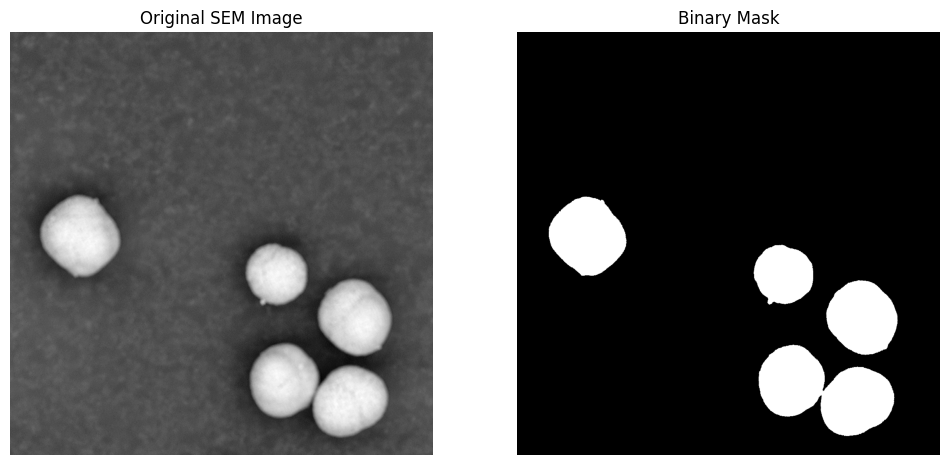

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from AutoPhenom import getSpotSpectrum
import time
import numpy as np
from AutoPhenom import AcquireSEMImage_at_current_location
import AutoPhenom as ap
import PyPhenom as ppi
import license
import os


# Perform contouring and center detection on an image that has been previously taken
# image_path = r"C:\PhenomData\NickelSpheres\Segmentation Project\Segmentation Practice Images\MultipleSpheres\Test3.tiff"
# image = cv2.imread(image_path, 0) # Load image in grayscale (0 corresponds to grayscale)


# Take a new image and perform EDS measurements on it
MainPath = r"C:\PhenomData\NickelSpheres\Segmentation Project\Testing\CD_Autonomous_Advertisement"
SavePath = ap.create_timestamped_folder(MainPath)
image_filename = 'SEM_image'
MainPath = "./"
image_path = AcquireSEMImage_at_current_location(SavePath, os.path.basename(image_filename), 1024)
image = cv2.imread(image_path, 0) # Load image in grayscale (0 corresponds to grayscale)

# Create threshold for binary mask
ret, thresh = cv2.threshold(image, 125, 255, cv2.THRESH_BINARY)

# === Plot original image and binary mask side by side ===
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Original image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original SEM Image')
axes[0].axis('off');

# Binary mask
axes[1].imshow(thresh, cmap='gray')
axes[1].set_title('Binary Mask')
axes[1].axis('off');

## Find contours in the image and filter out small and non-circular contours

Detected 3 particles


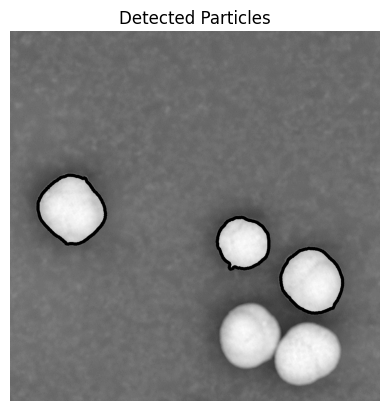

In [2]:
# Create copy of image where the contours will be drawn onto
image_copy = image.copy()

# Detect the contours
contours, _ = cv2.findContours(image=thresh, mode=cv2.RETR_TREE, method=cv2.CHAIN_APPROX_NONE)

# Filter out non-circular contours and small contours
filtered_contours = []
min_area = 5000 # Set minimum area threshold for a contour (in pixels)
for contour in contours:
    
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        continue  # Avoid division by zero and exclude contours that are too small
    
    # Exclude contours that are close to the edge of the image (since they may be partially cut off)
    x, y, w, h = cv2.boundingRect(contour)
    image_height, image_width = image.shape[:2]

    epsilon = 50  # Allow small tolerance
    if x <= epsilon or y <= epsilon or (x + w) >= image_width - epsilon or (y + h) >= image_height - epsilon:
        continue  # Exclude this contour

    circularity = 4 * np.pi * (area / (perimeter * perimeter))

    circularity_threshold = 0.75 # Set this from 0 to 1, with 1 being perfectly circular . 0.75 is a good choice
    
    if circularity > circularity_threshold and area > min_area:
        filtered_contours.append(contour)
        cv2.drawContours(image_copy, [contour], -1, (0, 255, 0), 8)

# see the results of contouring
print(f"Detected {len(filtered_contours)} particles")
plt.imshow(image_copy, cmap='gray');
plt.title("Detected Particles")
plt.axis('off')  # hides axes and ticks
plt.show()




## Create a 'Particle' class

In [3]:
class Particle():
 
    def __init__(self, name, center, sampling_points, radius, contour):
        self.name = name
        self.center = center
        self.sampling_points = sampling_points
        self.radius = radius
        self.contour = contour


## Function to convert pixel coordinates to EDS coordinates

In [4]:
def convert_pixels_to_EDS_coordinates(point, image):
    new_x_coordinate = point[0] / np.shape(image)[0]
    new_y_coordinate = point[1] / np.shape(image)[1]
    return (new_x_coordinate, new_y_coordinate)
    

## Find Centers and diameters of spheres

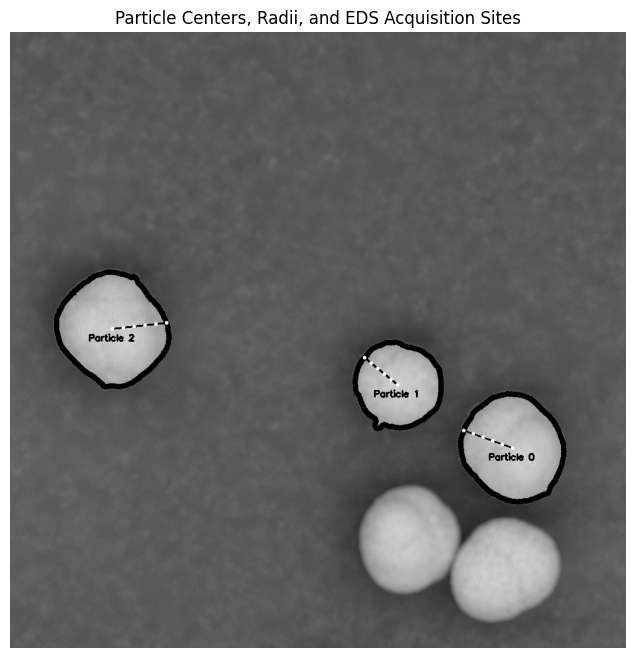

In [5]:
# Find the center and radius of each particle and add it to the particles list
particles = []
for i, contour in enumerate(filtered_contours):
    
    M = cv2.moments(contour)
    if M['m00'] != 0:
        # Use the centroid formula
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
        center = (cx, cy)

        
        # Get all distances from center to contour points
        contour_points = contour[:, 0, :] # reshapes the contour
        distances = np.linalg.norm(contour_points - center, axis=1)

        # Compute the mean distance from center to contour
        mean_val = np.mean(distances)

        # Find the index of the point whose distance is closest to the mean distance from center to edge
        average_edge_point_index = np.argmin(np.abs(distances - mean_val))

        # Get the point on the contour that is closest to the center (call this the edge point)
        average_edge_point = contour_points[average_edge_point_index]

        # Get the radius of the particle
        radius = np.linalg.norm(average_edge_point - center)

        # Draw the line between the center and the point closest to the mean distance
        cv2.line(image_copy, average_edge_point, center, color = (0, 255, 0), thickness = 2)

        # Plot the center of the sphere
        # cv2.circle(img = image_copy, center = center, radius = 7, color = (0, 0, 255), thickness = -1)
        # Calculate unit vector from center to edge
        vec = average_edge_point - center
      
        # vec_unit = vec / np.linalg.norm(vec)

        # # Calculate perpendicular unit vector by rotating 90 degrees (x,y) -> (-y,x)
        # perp_vec = np.array([-vec_unit[1], vec_unit[0]])

        # Offset text by 20 pixels along the perpendicular vector (tweak if needed)
        text_offset = 20
        # text_pos = center + perp_vec * text_offset

        # Determine text placement
        text_pos = list(center)
        if vec[1] > 0:
            text_pos[0] = center[0] - (2 * text_offset)
            text_pos[1] = center[1] - text_offset
        else:
            text_pos[0] = center[0] - (2 * text_offset)
            text_pos[1] = center[1] + text_offset
        
        text_pos = tuple(map(int, text_pos))

        cv2.putText(img = image_copy, text = f"Particle {i}", org = text_pos,
            fontFace = cv2.FONT_HERSHEY_SIMPLEX, fontScale = 0.5, color = (0, 0, 0), thickness = 2)

        # Pick out six points for EDS spot measurements that are equally spaced from center to edge point (inclusive)
        sampling_points = []
        for j in range(0, 6):
            point = center + (j / 5) * (average_edge_point - center)
            sampling_point = tuple(np.array(point).astype(int))
            sampling_points.append(sampling_point)
            cv2.circle(image_copy, sampling_point, radius = 3, color=(255, 0, 0), thickness=-1)
        
        # Instantiate the particle object 
        particle = Particle(f'Particle {i}', center, sampling_points, radius, contour)
        particles.append(particle)



# See the results of determining the center based on contours
plt.figure(figsize=(10, 8))
plt.imshow(image_copy, cmap='gray');
plt.title("Particle Centers, Radii, and EDS Acquisition Sites")
plt.axis('off')  # hides axes and ticks
plt.show()

## Take EDS measurements at the relevant points on each particle

Acquiring EDS spectra at Particle 0


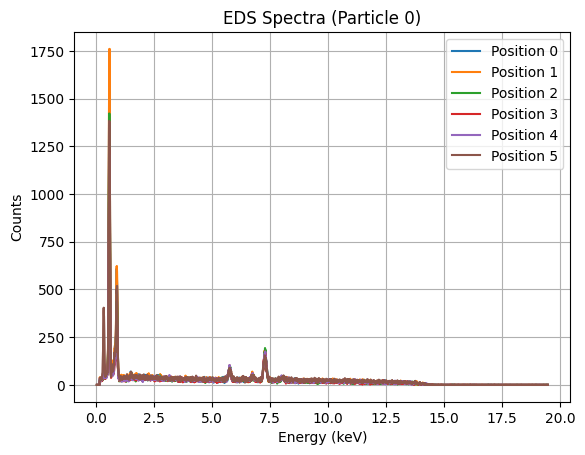

Acquired EDS Spectra at Particle 0 Position 0
Acquired EDS Spectra at Particle 0 Position 1
Acquired EDS Spectra at Particle 0 Position 2
Acquired EDS Spectra at Particle 0 Position 3
Acquired EDS Spectra at Particle 0 Position 4
Acquired EDS Spectra at Particle 0 Position 5
Acquiring EDS spectra at Particle 1


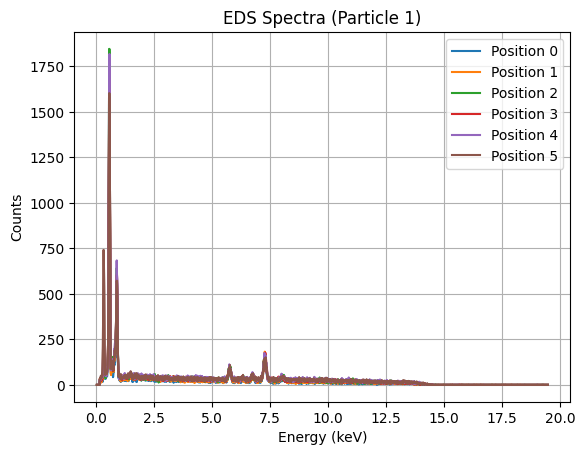

Acquired EDS Spectra at Particle 1 Position 0
Acquired EDS Spectra at Particle 1 Position 1
Acquired EDS Spectra at Particle 1 Position 2
Acquired EDS Spectra at Particle 1 Position 3
Acquired EDS Spectra at Particle 1 Position 4
Acquired EDS Spectra at Particle 1 Position 5
Acquiring EDS spectra at Particle 2


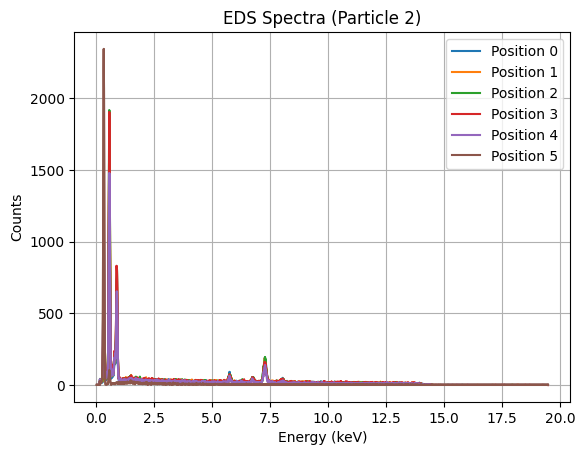

Acquired EDS Spectra at Particle 2 Position 0
Acquired EDS Spectra at Particle 2 Position 1
Acquired EDS Spectra at Particle 2 Position 2
Acquired EDS Spectra at Particle 2 Position 3
Acquired EDS Spectra at Particle 2 Position 4
Acquired EDS Spectra at Particle 2 Position 5


In [ ]:
from AutoPhenom import getSpotSpectrum
from AutoPhenom import initialize_marker_plot
from AutoPhenom import add_marker
from AutoPhenom import save_annotated_image
import time
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython import display


# Set up the phenom
address = ppi.FindPhenom(1).ip
phenom = ppi.Phenom(address,  license.PhenomUsername,  license.PhenomPassword)



# Loop through the particles
for particle in particles:
    # Set up the spectrometer
    dpp = phenom.Spectrometer
    settings = ppi.LoadEidSettings()
    dpp.ApplySettings(settings.spot)

    print(f"Acquiring EDS spectra at {particle.name}")

    # Initialize the EDS spectra dynamic plotting
    fig, ax = plt.subplots()
    dh = None # Don't display before the data has been acquired
    colors = plt.cm.tab10.colors  # 10 nice distinct colors


    # Loop through the previously determined number of points along the particle radius
    for i, sampling_point in enumerate(particle.sampling_points):
        # Convert the point to EDS coordinates
        sampling_point_EDS_coords = convert_pixels_to_EDS_coordinates(sampling_point, image)

        # Take EDS spot measurement
        size = (np.shape(image)[0], np.shape(image)[1])
        spectrum = getSpotSpectrum(sampling_point_EDS_coords[0], sampling_point_EDS_coords[1], size,SavePath,MainPath, image_path, dpp,settings,address,phenom,ppi, sample_name = "Nickel Spheres", dwell_time=5)

        # Dynamically update the plot
         # Pick a color for this line
        color = colors[i % len(colors)]
        # data = np.load(spectrum)
        x_values = np.arange(1, len(spectrum) + 1)
        x_values = (x_values * 9.485 + 39.926) / 1000 # If you want to convert to keV
        ax.plot(x_values, spectrum, color=color, label=f"Position {i}")
        ax.legend()
        ax.set_title(f'EDS Spectra ({particle.name})')
        ax.set_xlabel("Energy (keV)")
        ax.set_ylabel("Counts")
        ax.grid(True)
        ax.plot(x_values, spectrum)
        if dh is None:  # First time showing the figure
            dh = display.display(fig, display_id=True)
        else:
            dh.update(fig)
        time.sleep(0.1)

        print(f"Acquired EDS Spectra at {particle.name} Position {i}")




        # Annotate the SEM image with the EDS spot measurement locations
        os.chdir(SavePath)
        # add_marker(ax, image_shape, sampling_point_EDS_coords)

# Save the annotated SEM image
# image_with_spot_marks = save_annotated_image(fig, image_path)

# Get out of spot analysis mode
acqScanParams = ppi.ScanParams()
acqScanParams.size = ppi.Size(1024,1024) 
acqScanParams.detector = ppi.DetectorMode.All 
acqScanParams.nFrames = 16 
acqScanParams.hdr = False 
acqScanParams.center = ppi.Position(0,0)
acqScanParams.scale = 1.0
non_spot_mode = ppi.SemViewingMode(ppi.ScanMode.Imaging, acqScanParams)
phenom.SetSemViewingMode(non_spot_mode)

# Prevent the spectra plot from auto-displaying
plt.close('all')